### Loading the Dataset
#### Dataset Summary
Emotion is a dataset of English Twitter messages with six basic emotions: anger, fear, joy, love, sadness, and surprise. For more detailed information please refer to the paper.



In [97]:
from datasets import load_dataset

emotion = load_dataset('emotion')
emotion.set_format(type='pandas')

In [98]:
dataset=emotion

In [99]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [100]:
dataset['train'][:]

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
...,...,...
15995,i just had a very brief time in the beanbag an...,0
15996,i am now turning and i feel pathetic that i am...,0
15997,i feel strong and good overall,1
15998,i feel like this was such a rude comment and i...,3


In [101]:
classes = dataset['train'].features['label'].names
classes

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [102]:
dataset['train']

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

### Data Analysis

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

print('Train shape:', (len(dataset['train']), len(dataset['train'].column_names)))
print('Validation shape:', (len(dataset['validation']), len(dataset['validation'].column_names)))
print('Test shape:', (len(dataset['test']), len(dataset['test'].column_names)))

pd.DataFrame(dataset['train'][:5])

Train shape: (16000, 2)
Validation shape: (2000, 2)
Test shape: (2000, 2)


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


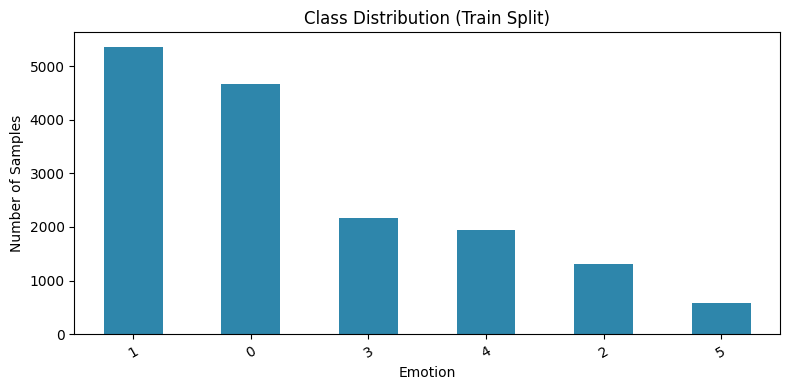

In [104]:
# Class distribution in train split
class_counts = pd.Series(dataset['train']['label']).value_counts().sort_values(ascending=False)
display(class_counts.to_frame('count'))

plt.figure(figsize=(8, 4))
class_counts.plot(kind='bar', color='#2E86AB')
plt.title('Class Distribution (Train Split)')
plt.xlabel('Emotion')
plt.ylabel('Number of Samples')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

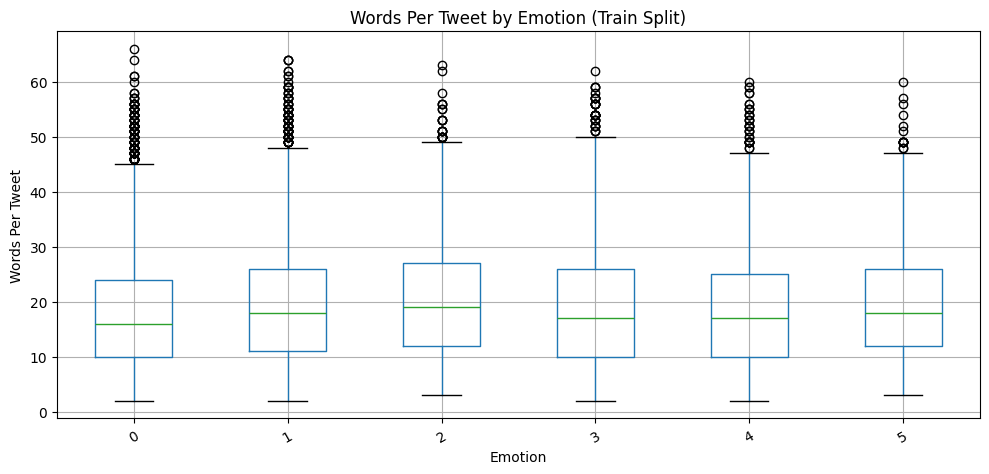

In [105]:
train_word_count = pd.DataFrame({
    'label_name': dataset['train']['label'],
    'Words Per Tweet': [len(str(t).split()) for t in dataset['train']['text']]
})

train_word_count.boxplot('Words Per Tweet', by='label_name', figsize=(10, 5))
plt.title('Words Per Tweet by Emotion (Train Split)')
plt.suptitle('')
plt.xlabel('Emotion')
plt.ylabel('Words Per Tweet')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Text Preprocessing

Use exactly the same preprocessing pipeline for all splits so the model sees text in the same format during:

Training (train)
Tuning/evaluation (validation)
Final evaluation or inference (test)

In [106]:
# import re

# # Expand common contractions first, then keep only lowercase words.
# contraction_map = {
#     "isn't": "is not", "isnt": "is not",
#     "didn't": "did not", "didnt": "did not",
#     "don't": "do not", "dont": "do not",
#     "can't": "can not", "cant": "can not",
#     "won't": "will not", "wont": "will not",
#     "i'm": "i am", "im": "i am",
#     "you're": "you are", "youre": "you are",
#     "it's": "it is", "its": "it is",
#     "that's": "that is", "thats": "that is",
#     "there's": "there is", "theres": "there is",
#     "we're": "we are", "were": "we are",
#     "they're": "they are", "theyre": "they are",
#     "i've": "i have", "ive": "i have",
#     "we've": "we have", "weve": "we have",
#     "they've": "they have", "theyve": "they have",
#     "i'll": "i will", "ill": "i will",
#     "you'll": "you will", "youll": "you will",
#     "we'll": "we will", "well": "we will",
#     "they'll": "they will", "theyll": "they will",
#     "i'd": "i would", "id": "i would",
#     "you'd": "you would", "youd": "you would",
#     "we'd": "we would", "wed": "we would",
#     "they'd": "they would", "theyd": "they would"
# }

# def preprocess_text(text):
#     text = str(text).lower().strip()

#     # Replace contractions as full-word matches only.
#     for short_form, full_form in contraction_map.items():
#         text = re.sub(rf"\b{re.escape(short_form)}\b", full_form, text)

#     # Keep only alphabetic words and spaces.
#     text = re.sub(r"[^a-z\s]", " ", text)
#     text = re.sub(r"\s+", " ", text).strip()

#     return text

# # Apply preprocessing directly to the text column.
# dataset = dataset.map(lambda x: {'text': preprocess_text(x['text']),"label": x["label"]})
# print(dataset['train'][:10])

### Tokenization

In [107]:
from transformers import AutoTokenizer
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

In [108]:
text = "I love Machine Learning!. Tokenization is awesome"
encoded_text = tokenizer(text)
print(encoded_text)

{'input_ids': [101, 1045, 2293, 3698, 4083, 999, 1012, 19204, 3989, 2003, 12476, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [109]:

tokens = tokenizer.convert_ids_to_tokens(encoded_text.input_ids)
print(tokens)


['[CLS]', 'i', 'love', 'machine', 'learning', '!', '.', 'token', '##ization', 'is', 'awesome', '[SEP]']


In [110]:

tokenizer.vocab_size, tokenizer.model_max_length


(30522, 512)

### Tokenization of Emotion Dataset

In [111]:
dataset.reset_format()

In [112]:
def tokenize(batch):
    # Shorter sequence length speeds up CPU training a lot
    return tokenizer(batch['text'], padding=True, truncation=True)

df_encoded = dataset.map(tokenize, batched=True,batch_size=None)


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [113]:
print(tokenize(dataset['train'][:2]))

{'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


In [114]:
df_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

### Model Building

In [115]:
import torch
from transformers import AutoModelForSequenceClassification

num_labels = len(classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels = num_labels).to(device)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### training

In [116]:
from transformers import TrainingArguments

# CPU-optimized fast training config
batch_size = 64
model_name = "distilbert-finetuned-emotion-fast"

training_args = TrainingArguments(
    output_dir = model_name,
    num_train_epochs=2,
    learning_rate = 2e-5,
    per_device_train_batch_size= batch_size,
    per_device_eval_batch_size = batch_size,
    weight_decay=0.01,
    eval_strategy = 'epoch',
    disable_tqdm=False)

In [117]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels, preds, average='weighted')
  acc = accuracy_score(labels, preds)
  return {"accuracy": acc, "f1": f1}


In [118]:
from transformers import Trainer

# Use only a subset for faster CPU training
# train_n = 8000
# val_n = 800
# test_n = 800

# train_ds = df_encoded['train'].shuffle(seed=42).select(range(min(train_n, len(df_encoded['train']))))
# val_ds = df_encoded['validation'].shuffle(seed=42).select(range(min(val_n, len(df_encoded['validation']))))
# test_ds = df_encoded['test'].shuffle(seed=42).select(range(min(test_n, len(df_encoded['test']))))

# print('Using samples -> train:', len(train_ds), 'val:', len(val_ds), 'test:', len(test_ds))

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=df_encoded['train'],
    eval_dataset=df_encoded['validation'],
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

In [119]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.323888,0.907500,0.907077
2,0.565681,0.231840,0.921500,0.921562


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=500, training_loss=0.5656809692382813, metrics={'train_runtime': 251.6109, 'train_samples_per_second': 127.18, 'train_steps_per_second': 1.987, 'total_flos': 720342861696000.0, 'train_loss': 0.5656809692382813, 'epoch': 2.0})

In [120]:
preds_outputs = trainer.predict(df_encoded['test'])
preds_outputs.metrics

{'test_loss': 0.23390237987041473,
 'test_accuracy': 0.9145,
 'test_f1': 0.9142844898777731,
 'test_runtime': 3.6052,
 'test_samples_per_second': 554.758,
 'test_steps_per_second': 8.876}

In [121]:
import numpy as np
y_preds = np.argmax(preds_outputs.predictions, axis=1)
y_true = df_encoded['test'][:]['label']

In [122]:
from sklearn.metrics import classification_report
print(classes)
print(classification_report(y_true, y_preds))

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       581
           1       0.94      0.94      0.94       695
           2       0.76      0.81      0.79       159
           3       0.94      0.92      0.93       275
           4       0.88      0.88      0.88       224
           5       0.75      0.65      0.70        66

    accuracy                           0.91      2000
   macro avg       0.87      0.86      0.86      2000
weighted avg       0.91      0.91      0.91      2000



In [123]:
# 5) Save once at the end (for Streamlit)
import os, json

artifact_dir = "distilbert-finetuned-emotion-fast"
os.makedirs(artifact_dir, exist_ok=True)

id2label = {i: label for i, label in enumerate(classes)}
label2id = {label: i for i, label in id2label.items()}
model.config.id2label = id2label
model.config.label2id = label2id

trainer.save_model(artifact_dir)
tokenizer.save_pretrained(artifact_dir)

with open(os.path.join(artifact_dir, "train_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(train_output.metrics, f, indent=2)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

NameError: name 'train_output' is not defined

In [124]:
!jupyter nbconvert --clear-output --inplace Emotion_detection.ipynb


[NbConvertApp] WARNING | pattern 'Emotion_detection.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execu